## Análise dos Dados Base

### Análise

##### Queries SQL
Para extrair conteúdo disponível diretamente na tabelas.

In [2]:
import sqlite3
import json

def count_table_rows(conn, table_name):
    try:
        with conn:
            cursor = conn.cursor()
            cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
            return cursor.fetchone()[0]
    except (sqlite3.OperationalError, Exception):
        return 0

def count_ads_by_display_format(conn):
    cursor = conn.cursor()
    cursor.execute("""
        SELECT display_format, COUNT(*)
        FROM advert
        GROUP BY display_format
    """)
    return {row[0]: row[1] for row in cursor.fetchall()}

def count_ads_by_media_type(conn):
    cursor = conn.cursor()
    cursor.execute("""
        SELECT media_format, COUNT(*)
        FROM media_card
        GROUP BY media_format
    """)
    return {row[0]: row[1] for row in cursor.fetchall()}

def get_ad_ids(conn):
    try:
        with conn:
            cursor = conn.cursor()
            cursor.execute(f"SELECT ad_archive_id FROM advert")
            return [id[0] for id in cursor.fetchall()]
    except (sqlite3.OperationalError, Exception):
        return []

def get_ad_detailing(conn, ad_id):
    cursor = conn.cursor()
    cursor.execute("SELECT metadata FROM advert WHERE ad_archive_id = ?", (ad_id,))
    row = cursor.fetchone()
    if row is None:
        return None
    return json.loads(row[0])


##### Queries JSON
Para extrair conteúdo dos JSONs armazenados na coluna Metadata, que precisam ser carregados como dicionários. 

In [3]:
def sort_dict(data, reverse=True):
    return sorted(data.items(), key=lambda item: item[1], reverse=reverse)

def print_pretty_dict(data, max=20):
    data = sort_dict(data)
    print("{")
    for n, entry in enumerate(data):
        if n >= max and max:
            break
        print(f"{entry[0]}: {entry[1]}")
    print("}")

def get_advertised_platforms(ad_metadata: dict):
    return ad_metadata.get("publisher_platform")

def get_lifetime(ad_metadata: dict):
    lifetime = {"start":ad_metadata.get("start_date"),
                "end":ad_metadata.get("end_date"),
                "current_active": ad_metadata.get("total_active_time")} # pode ser nulo
    lifetime["total"] = lifetime["end"]-lifetime["start"]
    return lifetime

def get_snapshot_data(ad_metadata: dict):
    snapshot = ad_metadata.get("snapshot")
    content = {
        "cta": snapshot.get("cta_type"),
        "categories": snapshot.get("page_categories"),
        "page_type": snapshot.get("page_entity_type")
    }
    return content


##### Plots

In [4]:
import matplotlib.pyplot as plt

def plot_bar_chart(data: dict, ylog=False, title="") -> None:
    sorted_items = sort_dict(data)
    categories, values = zip(*sorted_items)

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(categories, values, color='skyblue', edgecolor='black')

    ax.bar_label(bars, fmt='%.0f', padding=3)

    if ylog:
        ax.set_yscale('log')
        plt.ylabel('N° Anúncios (log)')

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=45, ha='right')

    plt.title(title)

    plt.tight_layout()
    plt.show()


##### Execução

{
WATCH_MORE: 4692
LEARN_MORE: 1206
SEE_DETAILS: 421
VIEW_INSTAGRAM_PROFILE: 389
SHOP_NOW: 337
DOWNLOAD: 317
INSTALL_MOBILE_APP: 138
PLAY_GAME: 113
SUBSCRIBE: 91
MESSAGE_PAGE: 84
WHATSAPP_MESSAGE: 76
None: 70
ORDER_NOW: 67
CONTACT_US: 58
INSTAGRAM_MESSAGE: 46
SIGN_UP: 28
APPLY_NOW: 21
BOOK_TRAVEL: 20
NO_BUTTON: 18
GET_QUOTE: 17
VISIT_PROFILE: 17
SEE_MORE: 10
BUY_TICKETS: 9
CALL_NOW: 8
LIKE_PAGE: 5
BOOK_NOW: 4
GET_OFFER: 4
INSTALL_APP: 4
GET_DIRECTIONS: 3
REQUEST_TIME: 2
LISTEN_NOW: 2
EVENT_RSVP: 1
CHECK_AVAILABILITY: 1
}
{
Episode: 1074
Movie: 468
Theater: 413
Topic: 374
Business: 326
TV show: 282
剧集: 268
Local business: 244
Profile: 243
电影: 232
Digital Creator: 186
Entertainment website: 164
Women's Clothing: 149
Children's Clothing: 146
Book: 141
Personal blog: 138
Education website: 129
TV channel: 126
Public figure: 124
Media/news company: 113
Men's Clothing: 107
Visual Arts: 106
Internet company: 101
Musician: 101
Health/beauty: 96
Business Center: 94
Software: 86
Health & Beauty:

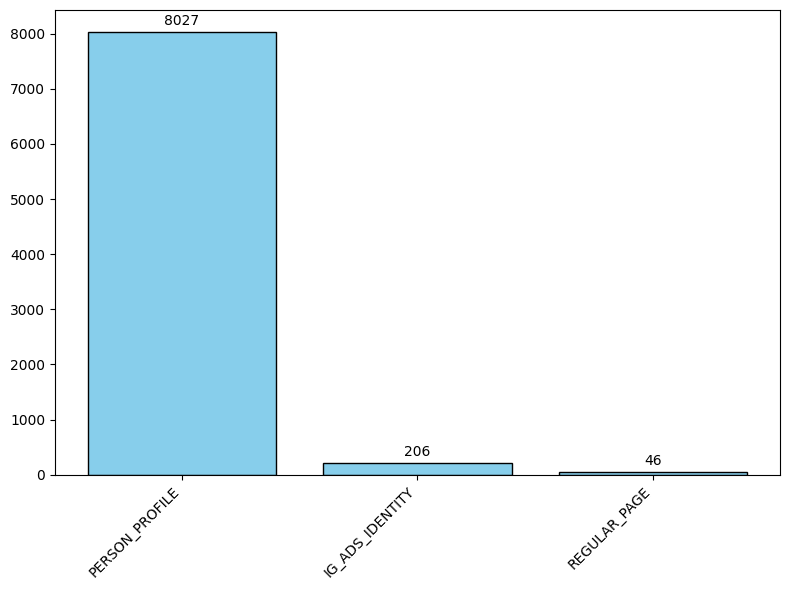

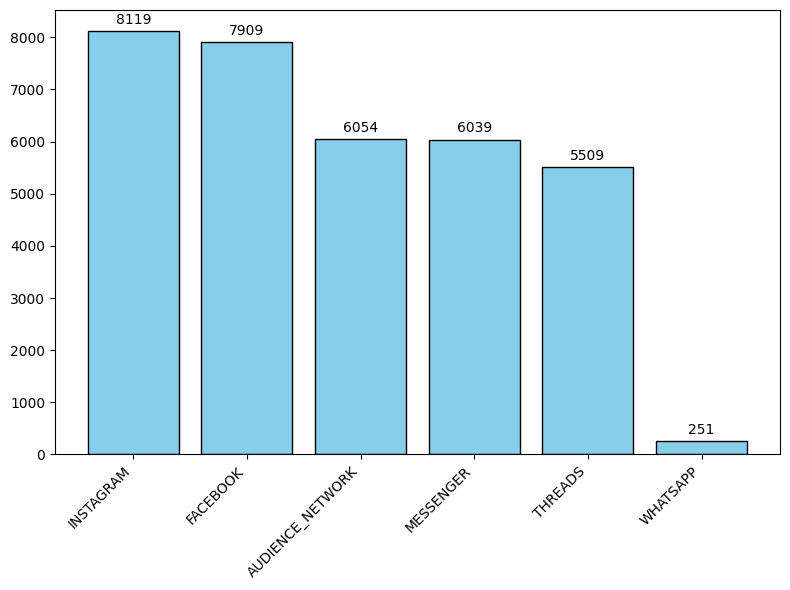

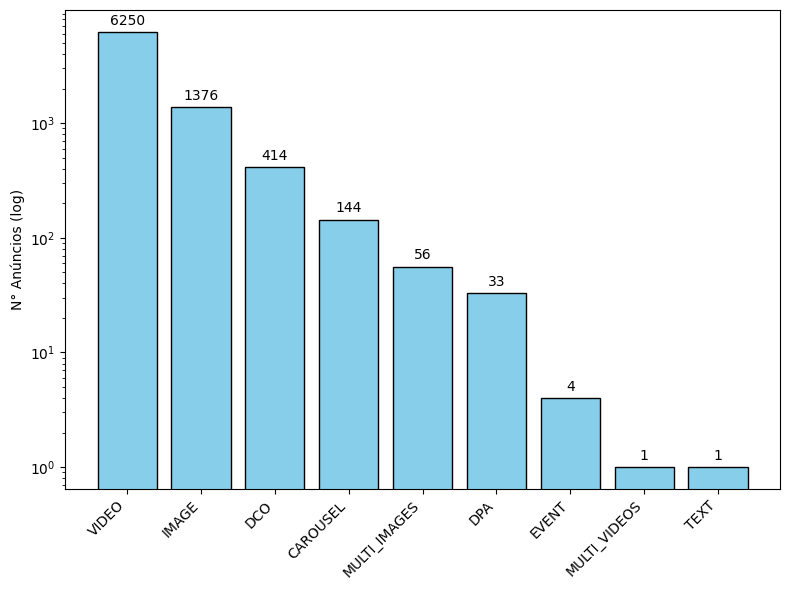

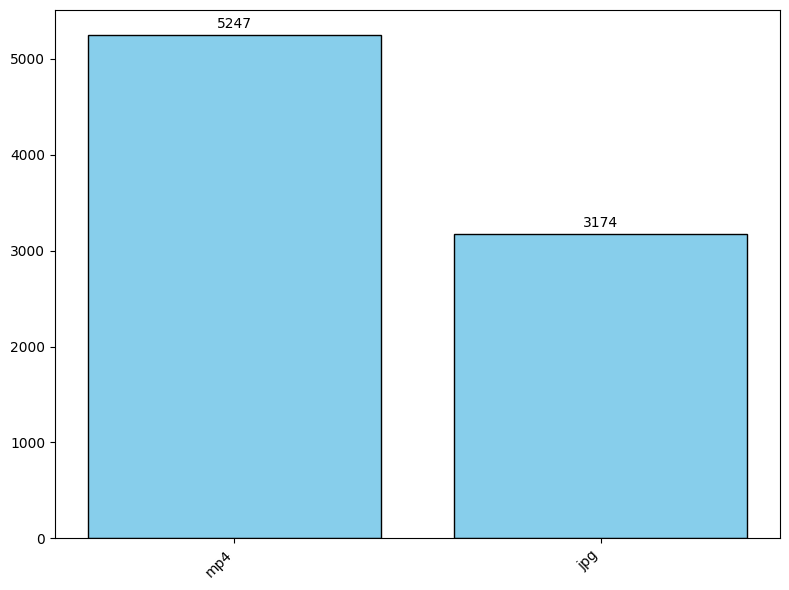

In [9]:
import random
from collections import defaultdict

db = sqlite3.connect("data/portugal.db")

advertiser_total = count_table_rows(db,"advertiser")
advert_total = count_table_rows(db,"advert")

ads_by_type = count_ads_by_display_format(db)
ads_by_media = count_ads_by_media_type(db)
#ads_by_media.pop("") # bug raro na meta onde mídias são salvas sem extensão na url

ids = get_ad_ids(db)
random.shuffle(ids)

platform_stats = defaultdict(int)
cta_stats = defaultdict(int)
account_stats = {
    "page_type": defaultdict(int),
    "category": defaultdict(int),
}

for ad in ids[:]:
    content = get_ad_detailing(db, ad)
    #print(ad)
    #print("\t",get_lifetime(content))
    #print("\t",get_snapshot_data(content), "\n")
    
    for plat in get_advertised_platforms(content):
        platform_stats[plat]+=1

    snap_data = get_snapshot_data(content)
    for item in snap_data["categories"]:
        account_stats["category"][item]+=1
    account_stats["page_type"][snap_data["page_type"]]+=1
    cta_stats[str(snap_data["cta"])]+=1


print_pretty_dict(cta_stats, False)
print_pretty_dict(account_stats["category"], max=150)
plot_bar_chart(account_stats["page_type"])
plot_bar_chart(platform_stats)
plot_bar_chart(ads_by_type, ylog=True)
plot_bar_chart(ads_by_media, ylog=False)